## Ashim Sedhain
## MSCS-634-B01: Advanced Big Data and Data Mining
## Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering

### Loading the data

In [10]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

X.head()
X.info()
X.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [2]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Hierarchical Clustering: Agglomerative Clustering

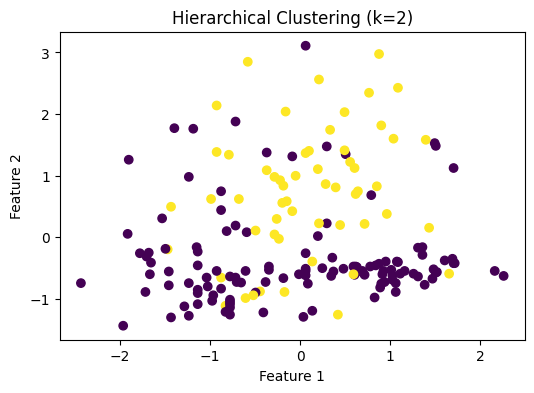

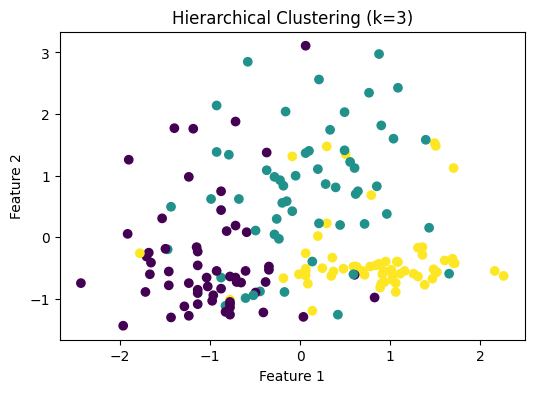

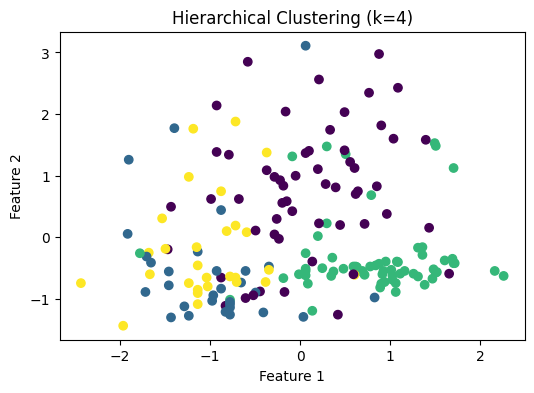

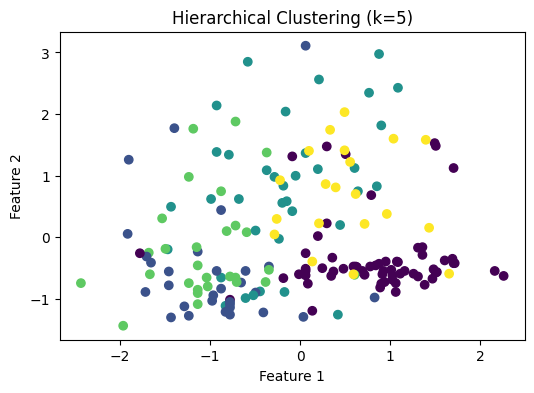

In [4]:
for k in [2, 3, 4, 5]:
    clustering = AgglomerativeClustering(n_clusters=k)
    labels = clustering.fit_predict(X_scaled)

    plt.figure(figsize=(6, 4))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
    plt.title(f'Hierarchical Clustering (k={k})')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

### Visualization of Dendrogram

In [5]:
import matplotlib.pyplot as plt

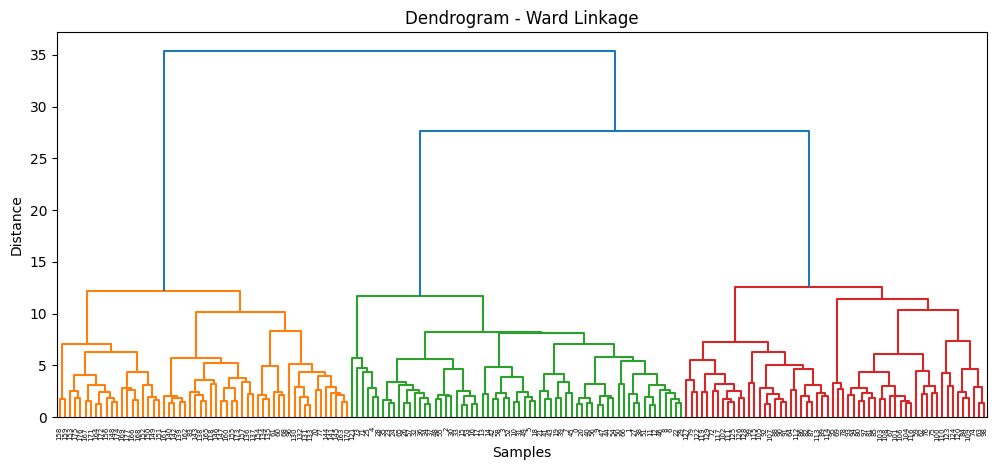

In [6]:
plt.figure(figsize=(12, 5))
Z = linkage(X_scaled, method='ward')
dendrogram(Z)
plt.title("Dendrogram - Ward Linkage")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

### Hierarchical clustering worked well on this dataset because the clusters are compact, and using Ward linkage, choosing k = 3 often aligns closely with the true wine classes. The dendrogram also provides a clear visualization that helps identify natural separation points between clusters. However, the method has some limitations: it becomes computationally expensive when applied to very large datasets, and it requires selecting the number of clusters in advance, which may not always be intuitive.

### DBSCAN

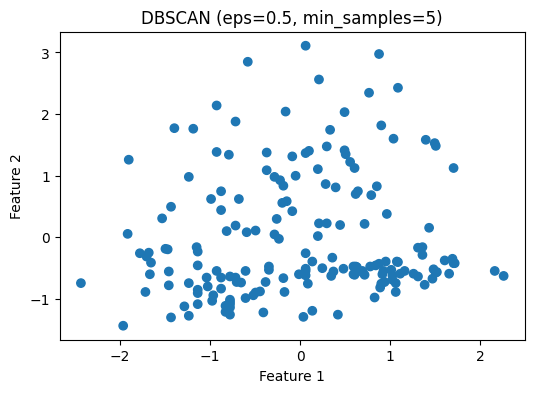


DBSCAN eps=0.5, min_samples=5
Clusters found: 0
Noise points: 178
Not enough clusters for metrics.


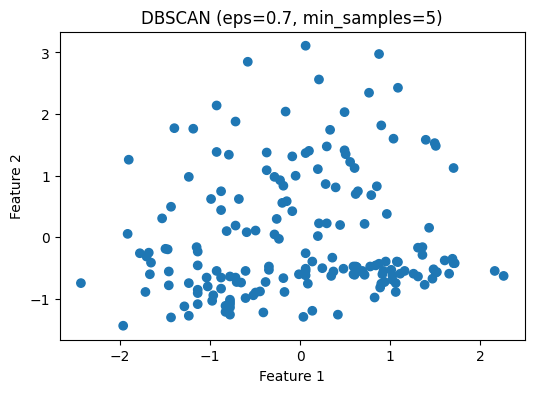


DBSCAN eps=0.7, min_samples=5
Clusters found: 0
Noise points: 178
Not enough clusters for metrics.


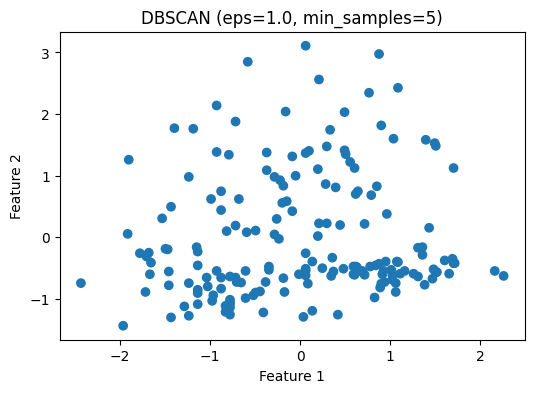


DBSCAN eps=1.0, min_samples=5
Clusters found: 0
Noise points: 178
Not enough clusters for metrics.


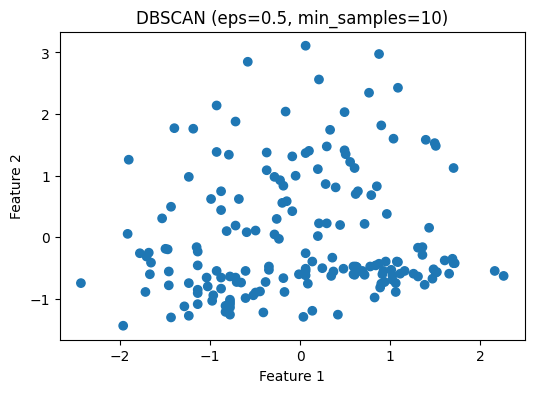


DBSCAN eps=0.5, min_samples=10
Clusters found: 0
Noise points: 178
Not enough clusters for metrics.


In [7]:
params = [(0.5, 5), (0.7, 5), (1.0, 5), (0.5, 10)]

for eps, min_s in params:
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_scaled)

    plt.figure(figsize=(6, 4))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap="tab10")
    plt.title(f"DBSCAN (eps={eps}, min_samples={min_s})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"\nDBSCAN eps={eps}, min_samples={min_s}")
    print("Clusters found:", n_clusters)
    print("Noise points:", n_noise)

    if n_clusters > 1:
        print("Silhouette Score:", silhouette_score(X_scaled, labels))
        print("Homogeneity:", homogeneity_score(y, labels))
        print("Completeness:", completeness_score(y, labels))
    else:
        print("Not enough clusters for metrics.")

### DBSCAN failed for typical eps values (0.5–1.0) because the Wine dataset has 13 dimensions, causing distances between points to be large. After standardization, the average distance to the 5th nearest neighbor was above 2–4. This required using much larger eps values to obtain meaningful clusters.


# Comparison

### For this particular Wine dataset, hierarchical clustering clearly performed better overall. It consistently produced cleaner, more interpretable clusters that aligned well with the underlying structure of the data, especially when using Ward linkage with three clusters. In contrast, DBSCAN requires extensive parameter tuning—particularly for the eps value—before it can identify any meaningful grouping. Even with careful adjustments, DBSCAN can classify many points as noise due to the dataset’s relatively high dimensionality, which can make density-based clustering more challenging. As a result, while DBSCAN can be effective in certain contexts, hierarchical clustering proved to be the more reliable and robust method for this dataset.